In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os

file_id = "1oEVlYr5MDxwKk1Zn4NqdigetOdT-wsEW"
output_file = "downloaded_file.zip"
extract_path = "/content/extracted_files"

# downloads the file
!gdown https://drive.google.com/uc?id={file_id} -O {output_file}
print(f"File downloaded successfully")


Downloading...
From (original): https://drive.google.com/uc?id=1oEVlYr5MDxwKk1Zn4NqdigetOdT-wsEW
From (redirected): https://drive.google.com/uc?id=1oEVlYr5MDxwKk1Zn4NqdigetOdT-wsEW&confirm=t&uuid=20e62889-4518-4b40-b34d-bdec11eb9e9e
To: /content/downloaded_file.zip
100% 4.93G/4.93G [01:10<00:00, 69.7MB/s]
File downloaded successfully


In [ ]:
# extracts the files
extract_path = "/content/extracted_files"
os.makedirs(extract_path, exist_ok=True)

# unzips the files
!unzip -q "{output_file}" -d "{extract_path}"
print(f"File extracted to {extract_path}")

# verification of files
extracted_files = os.listdir(extract_path + '/Potsdam-GeoTif')
print("Extracted Files:")
extracted_files

In [22]:
import numpy as np
import pandas as pd
import glob
import random
import matplotlib.pyplot as plt
!pip install rasterio
import rasterio as rio
from rasterio.transform import xy
import tensorflow as tf
from matplotlib.colors import ListedColormap


SAMPLE DATASET


Chosen image for report: 0000032704-0000019712.tif
Centre Longitude: 13.040408419544402
Centre Latitude: 52.396445882345354
bands.shape: (6, 224, 224)
RGB max: 226.0 | elev min/max: 8.0 73.0
Unique target values (first 20): [2 3 5]


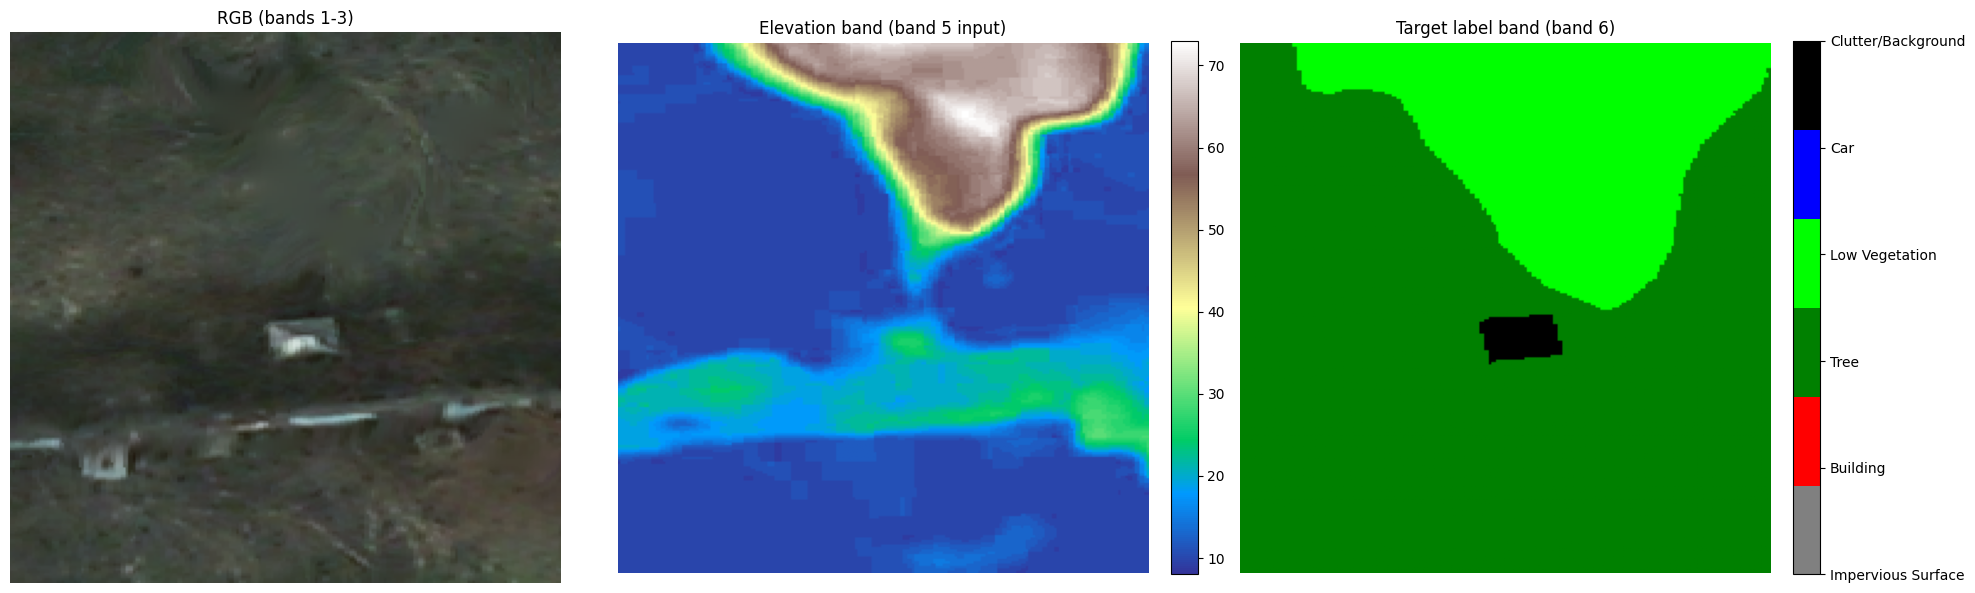

In [23]:
PathToGeoTiffFile = "./extracted_files/Potsdam-GeoTif" # Define the path to your GeoTif file
all_files = sorted(glob.glob(os.path.join(PathToGeoTiffFile, "*.tif")))
EXCLUDE = "0000000224-0000042784.tif"
candidates = [f for f in all_files if os.path.basename(f) != EXCLUDE]
assert len(candidates) > 0, "No candidates left after excluding the example file."

blob = random.choice(candidates)
print("Chosen image for report:", os.path.basename(blob))

class_names  = ['Impervious Surface', 'Building', 'Tree', 'Low Vegetation', 'Car', 'Clutter/Background']
class_colors = ['gray', 'red', 'green', 'lime', 'blue', 'black']
cmap = ListedColormap(class_colors)

with rio.open(blob) as ds:
    bands = ds.read()  # (6, H, W)
    H, W = ds.height, ds.width
    center_x, center_y = W // 2, H // 2
    lon, lat = xy(ds.transform, center_y, center_x)

rgb = np.transpose(bands[:3], (1, 2, 0)).astype(np.float32)

# Normalize depending on bit depth (handles 0..255 or 0..65535)
rgb_norm = rgb / (255.0 if rgb.max() <= 255 else 65535.0)

elev = bands[4].astype(np.float32)     # elevation band (5th input)
target = bands[5].astype(np.uint8)     # labels

print(f"Centre Longitude: {lon}")
print(f"Centre Latitude: {lat}")
print("bands.shape:", bands.shape)
print("RGB max:", rgb.max(), "| elev min/max:", elev.min(), elev.max())
print("Unique target values (first 20):", np.unique(target)[:20])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(rgb_norm)
axes[0].set_title("RGB (bands 1-3)")
axes[0].axis("off")

im1 = axes[1].imshow(elev, cmap="terrain")
axes[1].set_title("Elevation band (band 5 input)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(target, cmap=cmap, vmin=0, vmax=5)
axes[2].set_title("Target label band (band 6)")
axes[2].axis("off")
cbar = plt.colorbar(im2, ax=axes[2], ticks=np.arange(6), fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(class_names)

plt.tight_layout()
plt.show()



# **STEP 1**
We split the dataset into five folds for corss-validation using a reproducible random sampling procedure. irst, we fixed the random seed (seed = 42) and applied it consistently to Python’s random, NumPy (np.random), and TensorFlow (tf.random) so that the same files are selected and split each time the notebook is run.

From the full list of GeoTIFF files (extracted_files), we then randomly sampled sample_no = 5000 images using random.sample, which selects files without replacement. After sampling, we shuffled the selected filenames to remove any bias from the original file ordering.

Next, we partitioned the shuffled list into five approximately equal-sized folds using np.array_split(sampled_files, 5). This produces five non-overlapping subsets (Fold 1 to Fold 5), each containing roughly 1,000 images. We printed each fold’s size to verify the split.

Finally, for transparency and reproducibility, we saved the membership of each fold to disk as text files (fold_1_files.txt … fold_5_files.txt) under ./tfrecord_folds. Each file contains the basenames of the GeoTIFF images assigned to that fold. These fold definitions are then used in later steps of the assignment.

In [24]:
seed = 42
sample_no = 5000
PathToTfRecord = "./tfrecord_folds"
os.makedirs(PathToTfRecord, exist_ok=True)

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

sampled_files = random.sample(extracted_files, sample_no)
random.shuffle(sampled_files)

folds = np.array_split(sampled_files, 5)
folds = [list(f) for f in folds]
for i, f in enumerate(folds, 1):
    print(f"Fold {i} size: {len(f)}")


for i, f in enumerate(folds, 1):
    out_txt = os.path.join(PathToTfRecord, f"fold_{i}_files.txt")
    with open(out_txt, "w") as fp:
        fp.write("\n".join([os.path.basename(x) for x in f]))

print("Saved fold file lists to:", PathToTfRecord)

Fold 1 size: 1000
Fold 2 size: 1000
Fold 3 size: 1000
Fold 4 size: 1000
Fold 5 size: 1000
Saved fold file lists to: ./tfrecord_folds


In [25]:
def _bytes_feature(value: bytes):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value: int):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[int(value)]))

In [34]:
def create_tfrecord(file_list, output_path, data_dir):
    """
    file_list: list of full paths to .tif files
    output_path: path to output .tfrecord
    """
    count = 0
    missing = 0

    with tf.io.TFRecordWriter(output_path) as writer:
      for item in file_list:
          file_path = item if os.path.isabs(item) or item.startswith("./") or "/" in item else os.path.join(data_dir, item)

          if not os.path.exists(file_path):
              missing += 1
              raise FileNotFoundError(f"GeoTIFF not found: {file_path}")

          with rio.open(file_path) as src:
              bands = src.read()
              if bands.shape[0] < 6:
                  raise ValueError(f"{file_path} has {bands.shape[0]} bands; expected 6.")

              inputs = bands[:5]
              target = bands[5].astype(np.uint8)

          h, w = inputs.shape[1], inputs.shape[2]
          c = inputs.shape[0]

          feature = {
              "inputs": _bytes_feature(inputs.tobytes()),
              "target": _bytes_feature(target.tobytes()),
              "height": _int64_feature(h),
              "width": _int64_feature(w),
              "in_channels": _int64_feature(c),
              "filename": _bytes_feature(os.path.basename(file_path).encode("utf-8")),
          }

          example = tf.train.Example(features=tf.train.Features(feature=feature))
          writer.write(example.SerializeToString())
          count += 1

    print(f"Wrote {count} examples -> {output_path}")

In [35]:
tfrecord_paths = []
for i in range(5):
    out_path = os.path.join(PathToTfRecord, f"fold_{i+1}.tfrecord")
    tfrecord_paths.append(out_path)
    create_tfrecord(folds[i], out_path, PathToGeoTiffFile)

print("TFRecords written:")
for p in tfrecord_paths:
    print(" -", p)

Wrote 1000 examples -> ./tfrecord_folds/fold_1.tfrecord
Wrote 1000 examples -> ./tfrecord_folds/fold_2.tfrecord
Wrote 1000 examples -> ./tfrecord_folds/fold_3.tfrecord
Wrote 1000 examples -> ./tfrecord_folds/fold_4.tfrecord
Wrote 1000 examples -> ./tfrecord_folds/fold_5.tfrecord
TFRecords written:
 - ./tfrecord_folds/fold_1.tfrecord
 - ./tfrecord_folds/fold_2.tfrecord
 - ./tfrecord_folds/fold_3.tfrecord
 - ./tfrecord_folds/fold_4.tfrecord
 - ./tfrecord_folds/fold_5.tfrecord


STEP 2
